In [1]:
from __future__ import annotations

import copy
import io
import json
import logging
import math
import os
import random
import re
import sys
import time
import csv
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mne
import scipy.io as sio
import seaborn as sns
import yaml
from scipy.signal import butter, decimate, filtfilt, iirnotch, savgol_filter, sosfiltfilt
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Subset,DataLoader, Dataset

from renew import (
    get_device, set_seed,
    load_hs,extract_kt, load_participant,
    preprocess_kinematics_from_config,
    preprocess_emg_from_config,
    preprocess_eeg_from_config,
    WAYEEGDataset,
    HybridKGGTModel, build_model_from_config,
    CombinedEMGLoss, build_loss_from_config,
    train_model, TrainConfig, TrainResult,
    prepare_batch_factory, print_gpu_info, make_preprocess_fn, build_dataset_split,
    run_kfold_cross_validation, unique_series_arrays,
    predict_full_series_from_dataset,
    get_dynamic_fig_dir,
    save_fig,
    plot_multichannel_trace,
    plot_signal_heatmap,
    plot_preprocessing_comparison,
    plot_kinematic_features,
    plot_training_history,
    plot_prediction_overlay,
    plot_gate_heatmap,
    plot_attention_maps,
    plot_residual_diagnostics,
    plot_fused_pca,
    plot_gate_vs_emg_power,
    plot_emg_envelope_overlay
)

In [2]:
# @title Config
cfg = {
    "outputs":{
        "figures_dir": "docs/figure/method1_fix",
    },
    "data": {
        "raw_dir": "data/way-eeg/raw",
        "cache_dir": "data/cache_nb06",
        "participants": [4],
        "window_size": 4000,
        "stride": 250,
        "fs_eeg": 500,
        "fs_emg": 4000,
        "fs_kin": 500,
        "n_eeg_channels": 32,       # FIX: all 32, not 8
        "n_emg_channels": 5,
        "n_kin_raw": 36,
        "n_kin_features": 13
    },
    "preprocessing": {
        "eeg": {
            "bp_low": 0.5,
            "bp_high": 40.0,
            "artifact_method": "ica_auto",   # "asr" | "ica_auto" | "ica_manual"
            "filter_order": 4,
            "notch_freq": 50.0,
            "asr_window_ms": 250,
            "asr_std_thresh": 3.0,
            "asr_baseline_sec": 60.0,
            "delta_low": 0.5,
            "delta_high": 4.0,
            "use_car": False,
            # "target_channels": ["FC1", "FC2", "C3", "Cz", "C4", "CP1", "CP2", "CP6"]
        },
        "emg": {
            "bp_low": 30.0,
            "bp_high": 300.0,
            "filter_order": 4,
            "lp_cutoff": 10.0,
            "downsample_factor": 8
        },
        "kinematics": {
            "include_velocity": False,
            "velocity_method": "sg",
            "sg_window": 11,
            "sg_poly": 3,
            "bw_cutoff": 20.0,
            "bw_order": 4,
            "normalize": True
        },
        "cca": {
            "n_components": 8,
            "max_fit_samples": 100000,
            "random_state": 42
        }
    },
    "model": {
        "type": "transformer_regressor",
        "eeg_dim": 32,
        "kin_dim": 13,
        "d_model": 64,
        "pos_encoding": "sinusoidal", # local_attn_window: 50
        "transformer": {
            "n_layers": 4,
            "n_heads": 8,
            "d_model": 64,
            "d_k": 32,
            "ffn_dim": 256,
            "dropout": 0.1
        },
        "decoder": {
            "out_channels": 5,
            "hidden_dim": 128
        }
    },
    "training": {
        "loss_lambda": 1.0,
        "smooth_weight": 0.05,      
        "gate_weight": 0.01,        
        "soft_dtw_gamma": 0.1,
        "optimizer": "adamw",
        "lr": 1e-4,
        "weight_decay": 0.01,
        "batch_size": 32,
        "max_epochs": 50,
        "seed": 42,
        "lr_patience": 10,
        "lr_factor": 0.5,
        "grad_clip_norm": 1.0,
        "early_stop_patience": 15,
        "use_amp": False,
        "gradient_accumulation_steps": 2,
        "log_memory_every": 50,
        "checkpoint_dir": "data/cache/checkpoints",
        "checkpoint_every": 1
    }
}


In [3]:
# @title ConfigureNotebookExperiment
notebook_cfg = copy.deepcopy(cfg)

# Keep the current practical training choice from your config.
notebook_cfg["training"]["loss_lambda"] = cfg["training"]["loss_lambda"]

# Method 1 notebook should use the separate GAT pipeline.
notebook_cfg["model"]["type"] = "kg_gt_kinematic"

# These can be edited in-notebook for quick experiments.
participants = notebook_cfg["data"]["participants"]
batch_size = notebook_cfg["training"]["batch_size"]
max_epochs = notebook_cfg["training"]["max_epochs"]
smoke_run = True

device = get_device(prefer_cuda=True)
set_seed(notebook_cfg["training"].get("seed", 42), deterministic=False)
print("Device:", device)
print("Notebook model type:", notebook_cfg["model"]["type"])
print("Loss lambda:", notebook_cfg["training"]["loss_lambda"])
print("Smoke run:", smoke_run)
print("epoch:", max_epochs)


Device: cuda
Notebook model type: kg_gt_kinematic
Loss lambda: 1.0
Smoke run: True
epoch: 50


In [4]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CONFIG_PATH = ROOT / "configs" / "default.yaml"
METHOD1_TEX_PATH = ROOT / "data" / "review" / "EEGtoEMG" / "Final" / "report" / "method1.tex"
logger = logging.getLogger("method1_notebook")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

In [ ]:
# import shutil
# cache_path = ROOT / notebook_cfg["data"]["cache_dir"]
# if cache_path.exists():
#     print(f"Deleting old cache: {cache_path}")
#     shutil.rmtree(cache_path)
# else:
#     print(f"No cache found at {cache_path}")

In [5]:
# Use the paths and participant already defined in your notebook config
raw_data_dir = ROOT / notebook_cfg["data"]["raw_dir"]
participant_num = notebook_cfg["data"]["participants"][0]

p_dir = raw_data_dir / f"P{participant_num}"
if not p_dir.exists():
    print(f"Directory {p_dir} does not exist.")
else:
    ws_files = sorted(p_dir.glob(f"WS_P{participant_num}_S*.mat"))

    for f in ws_files:
        try:
            # Load the MAT file
            mat = sio.loadmat(str(f), squeeze_me=True, struct_as_record=False, mat_dtype=False)
            ws = mat["ws"]
            wins = ws.win
            
            # Make sure it's iterable even if there's only one task
            if not hasattr(wins, "__len__"):
                wins = [wins]
            
            lengths = []
            for w in wins:
                # Calculate duration based on the length of the time array and fs=500Hz
                lengths.append(len(w.eeg_t) / 500.0)
                
            print(f"Session {f.name}: {len(wins)} tasks, min duration: {np.min(lengths):.2f}s, "
                  f"max duration: {np.max(lengths):.2f}s, avg duration: {np.mean(lengths):.2f}s")
                  
        except Exception as e:
            print(f"Error processing {f.name}: {e}")


Session WS_P4_S1.mat: 34 tasks, min duration: 8.52s, max duration: 9.14s, avg duration: 8.79s
Session WS_P4_S2.mat: 28 tasks, min duration: 8.54s, max duration: 9.25s, avg duration: 8.83s
Session WS_P4_S3.mat: 34 tasks, min duration: 8.38s, max duration: 9.57s, avg duration: 8.85s
Session WS_P4_S4.mat: 28 tasks, min duration: 8.38s, max duration: 9.04s, avg duration: 8.68s
Session WS_P4_S5.mat: 34 tasks, min duration: 8.15s, max duration: 9.73s, avg duration: 8.67s
Session WS_P4_S6.mat: 34 tasks, min duration: 8.45s, max duration: 9.02s, avg duration: 8.67s
Session WS_P4_S7.mat: 34 tasks, min duration: 8.21s, max duration: 9.12s, avg duration: 8.59s
Session WS_P4_S8.mat: 34 tasks, min duration: 8.09s, max duration: 9.11s, avg duration: 8.52s
Session WS_P4_S9.mat: 34 tasks, min duration: 8.05s, max duration: 9.13s, avg duration: 8.50s


In [6]:
# Use the paths and participant already defined in your notebook config
raw_data_dir = ROOT / notebook_cfg["data"]["raw_dir"]
participant_num = notebook_cfg["data"]["participants"][0]

p_dir = raw_data_dir / f"P{participant_num}"
if not p_dir.exists():
    print(f"Directory {p_dir} does not exist.")
else:
    ws_files = sorted(p_dir.glob(f"WS_P{participant_num}_S*.mat"))

    for f in ws_files:
        try:
            # Load the MAT file
            mat = sio.loadmat(str(f), squeeze_me=True, struct_as_record=False, mat_dtype=False)
            wins = mat["ws"].win
            
            # Make sure it's iterable even if there's only one task
            if not hasattr(wins, "__len__"): 
                wins = [wins]
            
            # Extract weights and surfaces for all tasks in the session
            weights = [w.weight for w in wins]
            surfs = [w.surf for w in wins]
            
            unique_weights = len(set(weights))
            unique_surfs = len(set(surfs))
            
            # Determine the series type based on the paper's criteria
            if len(wins) == 28:
                series_type = "Mixed Series"
            elif unique_surfs > 1:
                series_type = "Friction/Surface Series"
            else:
                series_type = "Weight Series"
                
            print(f"{f.stem}: {len(wins)} tasks | {series_type}")
            
        except Exception as e:
            print(f"Error processing {f.name}: {e}")


WS_P4_S1: 34 tasks | Friction/Surface Series
WS_P4_S2: 28 tasks | Mixed Series
WS_P4_S3: 34 tasks | Weight Series
WS_P4_S4: 28 tasks | Mixed Series
WS_P4_S5: 34 tasks | Weight Series
WS_P4_S6: 34 tasks | Friction/Surface Series
WS_P4_S7: 34 tasks | Weight Series
WS_P4_S8: 34 tasks | Weight Series
WS_P4_S9: 34 tasks | Weight Series


In [ ]:
# @title Verify k_t extraction â€” compare against teammate manually

# Load one raw series (use same subject/series both notebooks touch)
raw_dir = ROOT / notebook_cfg["data"]["raw_dir"]
series = load_hs(raw_dir / "P1" / "HS_P1_S1.mat")  # adjust path to match

kin_raw = series["kin"]  # should be (T, 36)
kin_names = series["kin_names"]  # the actual names from the MAT file

print(f"Raw kin shape: {kin_raw.shape}")

# 1. Print raw 36-channel features and values first
print(f"\n{'='*65}")
print(f"  All 36 RAW Kinematic Channels")
print(f"{'='*65}")
print(f"{'Col':<4} {'Name':<25} {'mean':>9} {'std':>9} {'min':>9} {'max':>9}")
print("-" * 65)
for i in range(kin_raw.shape[1]):
    col = kin_raw[:, i]
    name = kin_names[i] if i < len(kin_names) else f"col{i}"
    print(f"{i:<4} {name:<25} {col.mean():>9.4f} {col.std():>9.4f} {col.min():>9.4f} {col.max():>9.4f}")


# 2. Explicit extraction with CORRECTED indices
# XYZ coords are stored by axis, not by sensor!

kt = extract_kt(kin_raw)

print(f"\n{'='*65}")
print(f"  Corrected 13-dim k_t Extraction")
print(f"{'='*65}")
print(f"k_t shape: {kt.shape}  (expect (T, 13))")

names = [
    "p_wrist_x (Px4)","p_wrist_y (Py4)","p_wrist_z (Pz4)",
    "p_index_x (Px2)","p_index_y (Py2)","p_index_z (Pz2)",
    "p_thumb_x (Px3)","p_thumb_y (Py3)","p_thumb_z (Pz3)",
    "d_grip (derived)", "F_L (FX1)", "F_G (FZ1, abs)", "rho_GL (derived)"
]

print(f"\n{'Dim':<4} {'Feature':<18} {'mean':>9} {'std':>9} {'min':>9} {'max':>9}")
print("-" * 65)
for i, name in enumerate(names):
    col = kt[:, i]
    print(f"{i:<4} {name:<18} {col.mean():>9.4f} {col.std():>9.4f} {col.min():>9.4f} {col.max():>9.4f}")

In [ ]:
kt = extract_kt(kin_raw)

# Feature names for the plot
kt_names = [
    "p_wrist_x", "p_wrist_y", "p_wrist_z",
    "p_index_x", "p_index_y", "p_index_z",
    "p_thumb_x", "p_thumb_y", "p_thumb_z",
    "d_grip", "F_L", "F_G", "rho_GL"
]

# 2. Plot all 13 selected features
fig = plot_multichannel_trace(
    kt[:6000],
    fs=series["fs_kin"],
    channel_names=kt_names[-6:],
    title="Selected Kinematic Features (k_t)",
    max_channels=6,   # Set to 13 to see all your selected features!
    cfg=notebook_cfg
)
plt.show()

In [ ]:
# @title InspectRawParticipantSeries
raw_dir = ROOT / notebook_cfg["data"]["raw_dir"]
participant = participants[0]
series_list = load_participant(raw_dir, participant=participant, file_type="hs", series=[1, 2], include_stability=False)
series = series_list[1]

print("Participant:", series["participant"])
print("Series:", series["series"])
print("EEG shape:", series["eeg"].shape)
print("EMG shape:", series["emg"].shape)
print("Kin shape:", series["kin"].shape)

fig = plot_multichannel_trace(series["eeg"][:5000], fs=series["fs_eeg"], channel_names=series["eeg_names"], title="Raw EEG preview", max_channels=6, cfg=notebook_cfg)
plt.show()                                             
fig = plot_multichannel_trace(series["emg"][:40000], fs=series["fs_emg"], channel_names=series["emg_names"], title="Raw EMG preview", max_channels=5 , cfg=notebook_cfg)
plt.show()

In [ ]:
# @title PreprocessingPipeline
eeg_processed = preprocess_eeg_from_config(
    series["eeg"],
    fs=series["fs_eeg"],
    cfg=notebook_cfg["preprocessing"]["eeg"],
    channel_names=series["eeg_names"],
)
emg_processed = preprocess_emg_from_config(
    series["emg"],
    fs=series["fs_emg"],
    cfg=notebook_cfg["preprocessing"]["emg"],
)
kin_features = preprocess_kinematics_from_config(
    series["kin"],
    fs=series["fs_kin"],
    cfg=notebook_cfg["preprocessing"]["kinematics"],
)

In [ ]:
# @title VisualizePreprocessingPipeline

fig = plot_preprocessing_comparison(                                                                       
    series["eeg"][:6000],                                                                            
    eeg_processed[:6000],                                                                            
    fs=series["fs_eeg"],                                                                             
    channel_idx=0,                                                                                   
    title_prefix="EEG",   
    cfg=notebook_cfg                                                                           
)                                                                                                    
plt.show()                                             
                                                                                                  
fig = plot_preprocessing_comparison(                                                                       
    series["emg"][:6000],                                                                            
    emg_processed[:6000],                                                                            
    fs=series["fs_eeg"],                                                                             
    channel_idx=0,                                                                                   
    title_prefix="EMG envelope",  
    cfg=notebook_cfg                                                                   
)                                                                                                    
plt.show()                                             
                   

fig = plot_signal_heatmap(                                                                                 
    eeg_processed[:1200],                                                                            
    title="Processed EEG heatmap",                                                                   
    cmap="viridis",    
    cfg=notebook_cfg                                                                              
)                                                                                                    
plt.show()                                             
                                                                                                    
fig = plot_signal_heatmap(                                                                                 
    emg_processed[:1200],                                                                            
    title="Processed EMG heatmap",                                                                   
    channel_names=series["emg_names"],                                                               
    cmap="magma",     
    cfg=notebook_cfg                                                                               
)                                                                                                    
plt.show()                                             
                                                                                                    
fig = plot_kinematic_features(                                                                             
    kin_features[:6000],                                                                             
    fs=series["fs_kin"],                                                                             
    max_features=6,      
    cfg=notebook_cfg                                                                            
)                                                                                                    
plt.show()                                             

In [ ]:
# @title Visualize Step-by-Step EMG Preprocessing
import numpy as np
import matplotlib.pyplot as plt
from renew.preprocessing_emg_kin import bandpass, rectify, lowpass_envelope, downsample
from renew import plot_multichannel_trace

# 1. Setup - grab a 2-second snippet of raw EMG data
emg_cfg = notebook_cfg["preprocessing"]["emg"]
fs_emg = series["fs_emg"]
samples_to_plot = int(12.0 * fs_emg)  # 2 seconds
emg_raw = series["emg"][:samples_to_plot]
emg_names = series["emg_names"]

# Step 1: Raw EMG
fig1 = plot_multichannel_trace(
    emg_raw, fs=fs_emg, channel_names=emg_names, 
    title="Step 1: Raw EMG", cfg=notebook_cfg
)

# Step 2: Bandpass Filter (e.g., 30 - 300 Hz) to remove noise/artifacts
emg_bp = bandpass(
    emg_raw, fs_emg, 
    low=emg_cfg["bp_low"], 
    high=emg_cfg["bp_high"], 
    order=emg_cfg["filter_order"]
)
fig2 = plot_multichannel_trace(
    emg_bp, fs=fs_emg, channel_names=emg_names, 
    title=f"Step 2: Bandpass Filtered ({emg_cfg['bp_low']}-{emg_cfg['bp_high']} Hz)", 
    cfg=notebook_cfg
)

# Step 3: Rectification (Absolute value to make all signals positive)
emg_rect = rectify(emg_bp)
fig3 = plot_multichannel_trace(
    emg_rect, fs=fs_emg, channel_names=emg_names, 
    title="Step 3: Rectified EMG (Absolute Value)", cfg=notebook_cfg
)

# Step 4: Low-pass Filter for Envelope Extraction (e.g., 10 Hz)
emg_env = lowpass_envelope(
    emg_rect, fs_emg, 
    cutoff=emg_cfg["lp_cutoff"], 
    order=emg_cfg["filter_order"]
)
fig4 = plot_multichannel_trace(
    emg_env, fs=fs_emg, channel_names=emg_names, 
    title=f"Step 4: Envelope Extraction (Low-pass {emg_cfg['lp_cutoff']} Hz)", 
    cfg=notebook_cfg
)

# Step 5: Downsampling
downsample_factor = emg_cfg["downsample_factor"]
emg_downsampled = downsample(emg_env, factor=downsample_factor)
fs_emg_new = fs_emg / downsample_factor

fig5 = plot_multichannel_trace(
    emg_downsampled, fs=fs_emg_new, channel_names=emg_names, 
    title=f"Step 5: Downsampled (Factor: {downsample_factor}, New FS: {fs_emg_new} Hz)", 
    cfg=notebook_cfg
)

fig_overlay = plot_emg_envelope_overlay(
    raw_emg=emg_raw,          # 4000 Hz raw data
    env_emg=emg_downsampled,  # 500 Hz processed envelope
    fs_raw=fs_emg,
    fs_env=fs_emg_new,
    channel_idx=0,
    channel_name=emg_names[0],
    title=f"EMG Overlay: {emg_names[0]}",
    figsize=(12, 5),
    cfg=notebook_cfg
)

fig_overlay = plot_emg_envelope_overlay(
    raw_emg=emg_raw,          # 4000 Hz raw data
    env_emg=emg_downsampled,  # 500 Hz processed envelope
    fs_raw=fs_emg,
    fs_env=fs_emg_new,
    channel_idx=1,
    channel_name=emg_names[1],
    title=f"EMG Overlay: {emg_names[1]}",
    figsize=(12, 5),
    cfg=notebook_cfg
)

fig_overlay = plot_emg_envelope_overlay(
    raw_emg=emg_raw,          # 4000 Hz raw data
    env_emg=emg_downsampled,  # 500 Hz processed envelope
    fs_raw=fs_emg,
    fs_env=fs_emg_new,
    channel_idx=2,
    channel_name=emg_names[2],
    title=f"EMG Overlay: {emg_names[2]}",
    figsize=(12, 5),
    cfg=notebook_cfg
)

fig_overlay = plot_emg_envelope_overlay(
    raw_emg=emg_raw,          # 4000 Hz raw data
    env_emg=emg_downsampled,  # 500 Hz processed envelope
    fs_raw=fs_emg,
    fs_env=fs_emg_new,
    channel_idx=3,
    channel_name=emg_names[3],
    title=f"EMG Overlay: {emg_names[3]}",
    figsize=(12, 5),
    cfg=notebook_cfg
)

fig_overlay = plot_emg_envelope_overlay(
    raw_emg=emg_raw,          # 4000 Hz raw data
    env_emg=emg_downsampled,  # 500 Hz processed envelope
    fs_raw=fs_emg,
    fs_env=fs_emg_new,
    channel_idx=4,
    channel_name=emg_names[4],
    title=f"EMG Overlay: {emg_names[4]}",
    figsize=(12, 5),
    cfg=notebook_cfg
)

plt.show()


In [7]:
# @title BuildDatasets
train_ds = build_dataset_split(notebook_cfg, participants=participants, split="train", root_dir=ROOT)
val_ds = build_dataset_split(notebook_cfg, participants=participants, split="val", root_dir=ROOT)
test_ds = build_dataset_split(notebook_cfg, participants=participants, split="test", root_dir=ROOT)

print(train_ds)
print(val_ds)
print(test_ds)


WAYEEGDataset(split='train', participants=[4], n_windows=3679, window_size=4000, stride=250)
WAYEEGDataset(split='val', participants=[4], n_windows=959, window_size=4000, stride=250)
WAYEEGDataset(split='test', participants=[4], n_windows=1317, window_size=4000, stride=250)


In [8]:
# @title Build Hybrid Model & Setup

sample_eeg, sample_kin, sample_emg = train_ds[0]
drop_kin_indices = [12] # Drop rho_GL (index 12)

print("Computing dataset statistics to enforce Z-score normalization...")
_, tr_kin, tr_emg = unique_series_arrays(train_ds)

emg_concat = np.concatenate(tr_emg, axis=0)
emg_mean_tensor = torch.tensor(emg_concat.mean(0), dtype=torch.float32, device=device)
emg_std_tensor = torch.tensor(emg_concat.std(0) + 1e-8, dtype=torch.float32, device=device)

kin_concat = np.concatenate(tr_kin, axis=0)
kin_mean_tensor = torch.tensor(kin_concat.mean(0), dtype=torch.float32, device=device)
kin_std_tensor = torch.tensor(kin_concat.std(0) + 1e-8, dtype=torch.float32, device=device)

# Prepare batch WITH the true scaling tensors and drop_kin_indices
prepare_batch = prepare_batch_factory(
    emg_mean=emg_mean_tensor,
    emg_std=emg_std_tensor,
    kin_mean=kin_mean_tensor,
    kin_std=kin_std_tensor,
    device=device,
    drop_kin_indices=drop_kin_indices
)

# Infer dynamically:
dummy_eeg, dummy_kin, dummy_emg = train_ds[0]
dummy_eeg = torch.as_tensor(dummy_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(dummy_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(dummy_emg).unsqueeze(0)
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)

true_eeg_dim = batch_inputs["eeg"].shape[-1]
# prepare_batch already dropped the feature, so the output shape IS the final dimension
true_kin_dim = batch_inputs["kin"].shape[-1]

model = build_model_from_config(
    notebook_cfg, 
    input_dim=true_eeg_dim, 
    kin_dim=true_kin_dim
).to(device)

loss_fn = build_loss_from_config(notebook_cfg["training"]).to(device)



Computing dataset statistics to enforce Z-score normalization...


In [9]:
# @title Setup Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=device.type == "cuda"
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=device.type == "cuda"
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=device.type == "cuda"
)


In [10]:
# @title Train Hybrid Model via K-Fold Cross Validation

all_fold_results, save_folder = run_kfold_cross_validation(
    notebook_cfg=notebook_cfg,
    train_ds=train_ds,          # Your full training dataset object
    batch_size=batch_size,      # E.g., 32 or 64 from your earlier cell
    prepare_batch=prepare_batch,# Your scaling factory
    loss_fn=loss_fn,            # e.g., nn.MSELoss()
    device=device,
    train_model_func=train_model, # The framework's standard training loop 
    resume = True,
    smoke_run=False,        # If True, trains 1 epoch. If False, uses max_epochs from config
    k_folds= 5                  # Standard 5-fold split
)

print(f"\nSuccess! All K-Fold assets, checkpoints, and plots are inside: {save_folder}")

Results and Checkpoints will be saved to: results\P4\ep50_st250_lr0.0001_bs32


K-Fold Progress:   0%|          | 0/5 [00:00<?, ?it/s]

INFO | Training on cuda | AMP=False | epochs=50 | lr=0.0001 | ckpt_dir=results\P4\ep50_st250_lr0.0001_bs32\fold_1\checkpoints
INFO | Resumed from results\P4\ep50_st250_lr0.0001_bs32\fold_1\checkpoints\last.pt  (epoch 50 done, best_val=0.2218)


  GPU / Device Status
  OK  Device index    : cuda:0
  OK  GPU name        : NVIDIA GeForce GTX 1660 Ti
  OK  CUDA capability : sm_75
  OK  VRAM (total)    : 6,144 MB
  OK  VRAM allocated  : 18.7 MB
  OK  VRAM reserved   : 26.0 MB
  OK  CUDA version    : 12.6
  OK  PyTorch build   : 2.8.0+cu126
  OK  AMP (FP16)      : YES -- Turing tensor cores active

Resumed from checkpoint: results\P4\ep50_st250_lr0.0001_bs32\fold_1\checkpoints\last.pt
  Completed epochs : 50
  Best val loss    : 0.2218
  Early-stop bad   : 0/15


Training done.  Best val loss = 0.2218
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\results\P4\ep50_st250_lr0.0001_bs32\fold_1\checkpoints


INFO | Training on cuda | AMP=False | epochs=50 | lr=0.0001 | ckpt_dir=results\P4\ep50_st250_lr0.0001_bs32\fold_2\checkpoints
INFO | Resumed from results\P4\ep50_st250_lr0.0001_bs32\fold_2\checkpoints\last.pt  (epoch 50 done, best_val=0.2126)


...

  Ep   49 [val  ]:   0%|          | 0/23 [00:00<?, ?batch/s]

  Ep   50 [train]:   0%|          | 0/92 [00:00<?, ?batch/s]

  Ep   50 [val  ]:   0%|          | 0/23 [00:00<?, ?batch/s]

INFO | Ep   50/50 | train 0.2153 | val 0.2156 | lr 1.00e-04 | 134.4s | VRAM 38/6144 MB  <- BEST



Training done.  Best val loss = 0.2156
Checkpoints saved to: D:\Research\Interdisciplinary-Schools\Computational-NeuroScience\Team6-2025\results\P4\ep50_st250_lr0.0001_bs32\fold_5\checkpoints

All 5 Folds Completed! Checkpoints saved in: results\P4\ep50_st250_lr0.0001_bs32

Success! All K-Fold assets, checkpoints, and plots are inside: results\P4\ep50_st250_lr0.0001_bs32


Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\training_history.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\training_history.pdf


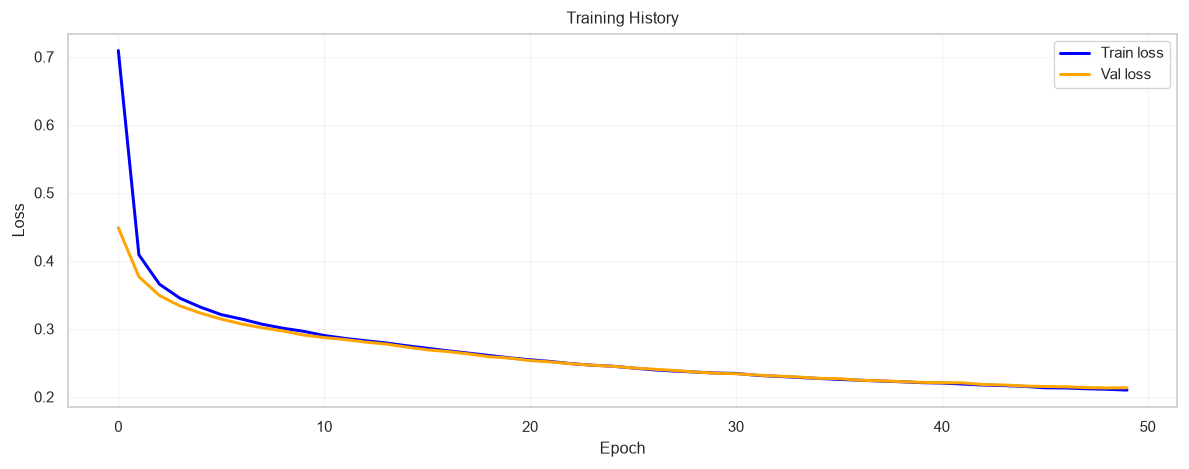

In [11]:
# @title Plot Loss Curve

fold_index = 2
fold_result = all_fold_results[fold_index]

fig_loss = plot_training_history(fold_result.history, cfg=notebook_cfg)

In [12]:
def get_checkpoint_path(cfg, fold_idx):
    """Dynamically reconstructs the path to best.pt for any given fold."""
    max_epochs = cfg["training"]["max_epochs"]
    stride = cfg["data"]["stride"]
    lr = cfg["training"].get("lr", 1e-4)
    bs = cfg["training"]["batch_size"]
    config_str = f"ep{max_epochs}_st{stride}_lr{lr}_bs{bs}"
    
    participants = cfg["data"].get("participants", [])
    subject_str = f"P{participants[0]}" if participants else "unknown"
    return Path("results") / subject_str / config_str / f"fold_{fold_idx + 1}" / "checkpoints" / "best.pt"


In [14]:
# @title Extract Attention Weights

# 1. Build a fresh base model
sample_eeg, sample_kin, sample_emg = test_ds[0]
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)

# We use prepare_batch to get the true dimensions after feature dropping
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)

model = build_model_from_config(
    notebook_cfg, 
    input_dim=batch_inputs["eeg"].shape[-1], 
    kin_dim=batch_inputs["kin"].shape[-1]
).to(device)

# --- LOAD SAFELY FROM THE HARD DRIVE INSTEAD OF RAM ---
# Let's load Fold 4 (index 3) since you were looking at that one!
checkpoint_path = get_checkpoint_path(notebook_cfg, fold_idx=2) 
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Successfully loaded checkpoint from: {checkpoint_path.parent.parent.name}")

# 2. Grab a single batch from the test loader
for batch in test_loader:
    eeg_batch, kin_batch, emg_batch = batch
    model_inputs, emg_targets = prepare_batch(eeg_batch, kin_batch, emg_batch)
    break

# 3. Forward pass requesting the attention weights
# with torch.no_grad():
#     interpret_dict = model(
#         model_inputs["eeg"], 
#         model_inputs["kin"], 
#         return_attention=True
#     )
#     preds = interpret_dict["prediction"]

# 3. Forward pass requesting the attention weights (ONLY for the first sample!)
with torch.no_grad():
    interpret_dict = model(
        model_inputs["eeg"][:1],  # <--- Notice the [:1] here
        model_inputs["kin"][:1],  # <--- Notice the [:1] here
        return_attention=True
    )
    preds = interpret_dict["prediction"]

print("Attention weights & Fused variables successfully extracted!")



Successfully loaded checkpoint from: fold_3
Attention weights & Fused variables successfully extracted!


Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\gate_heatmap.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\gate_heatmap.pdf


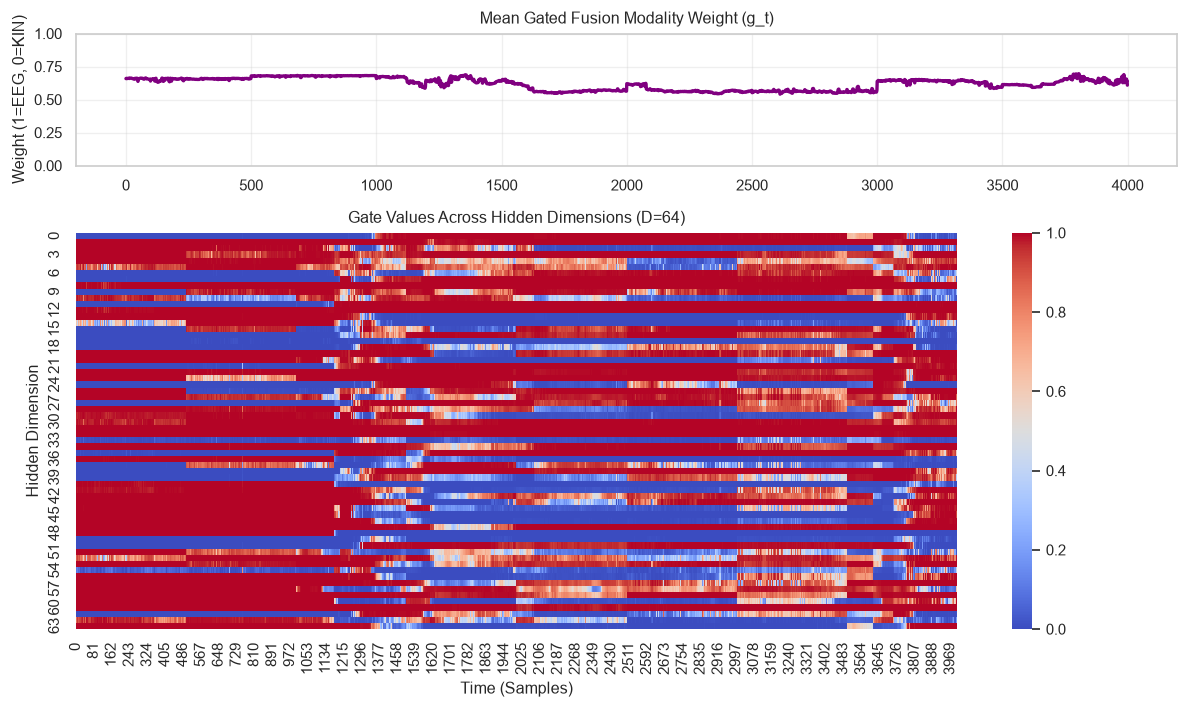

Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\eeg_to_kin_cross_attention_mean.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\eeg_to_kin_cross_attention_mean.pdf
Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\eeg_to_kin_cross_attention_per_head.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\eeg_to_kin_cross_attention_per_head.pdf
Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\kin_to_eeg_cross_attention_mean.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\kin_to_eeg_cross_attention_mean.pdf
Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\kin_to_eeg_cross_attention_per_head.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\kin_to_eeg_cross_attention_per_head.pdf
Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\self_attention_final_layer_mean.png
  results\P4\ep50_st250_lr0.0001_bs32\plots\self_attention_final_layer_mean.pdf
Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\plots\self_attention_final_layer_per_head.png
  results\P4\ep5

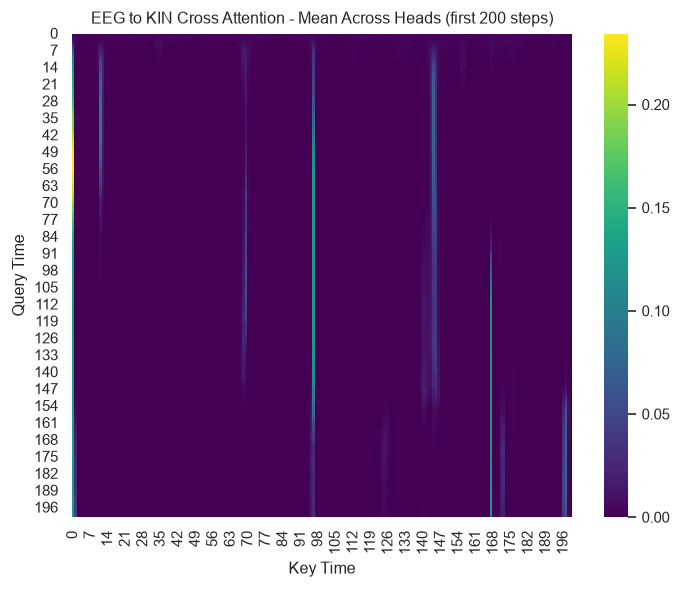

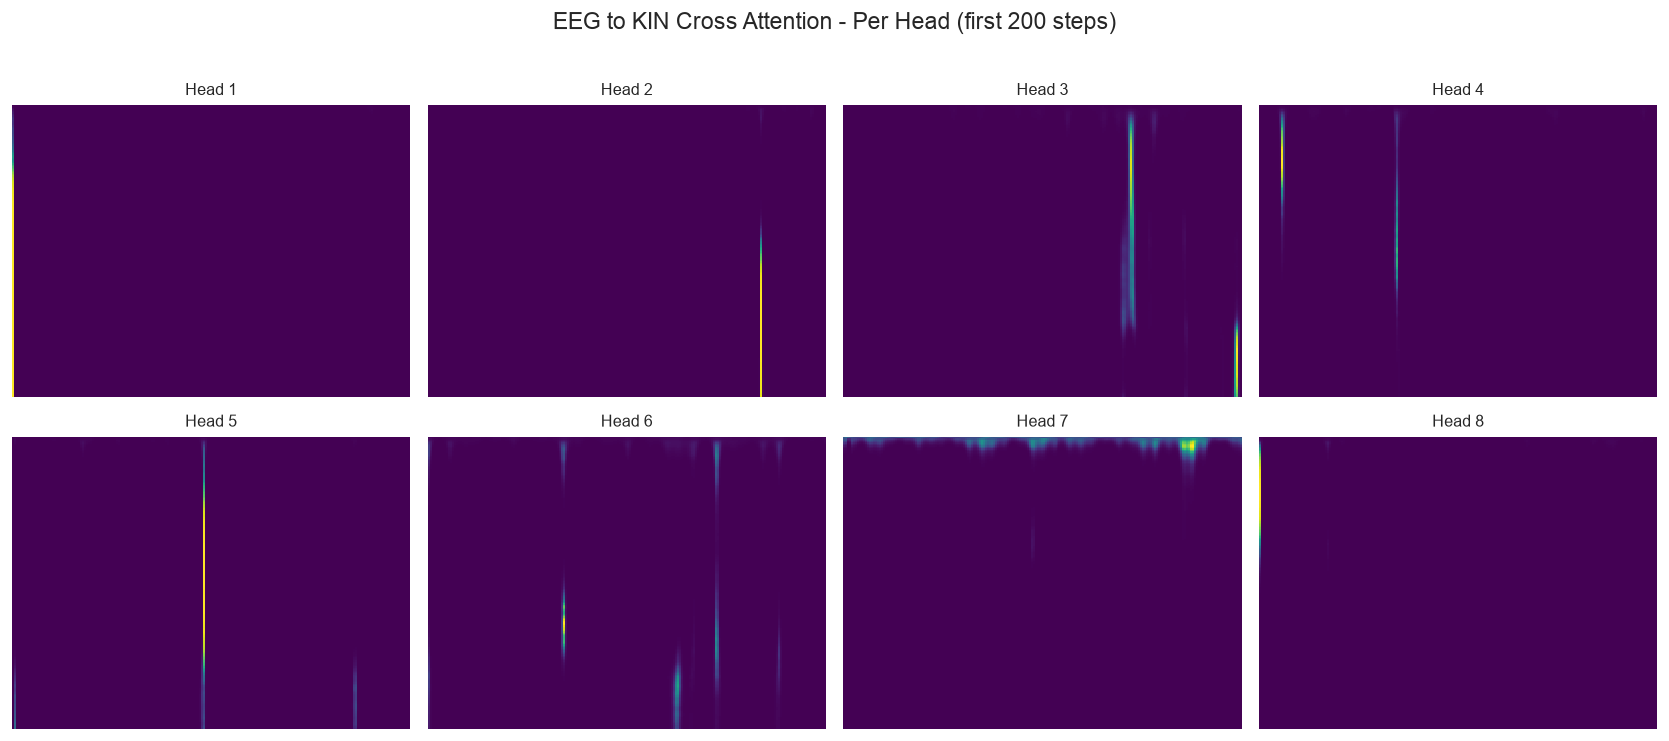

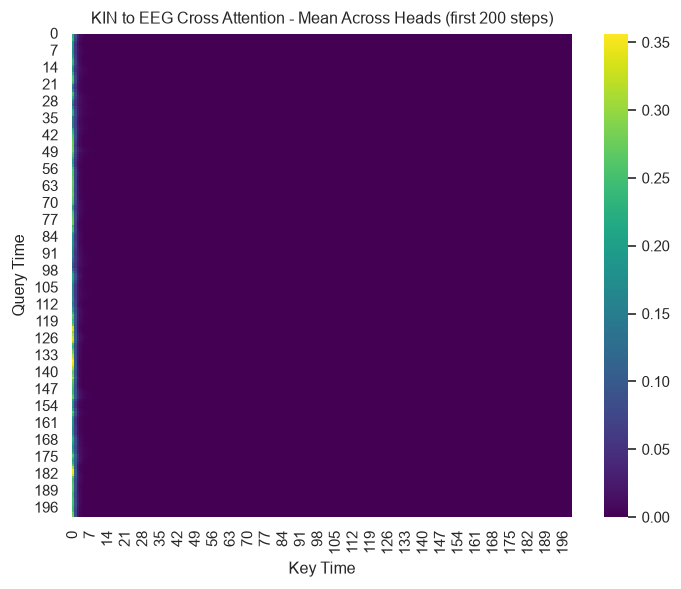

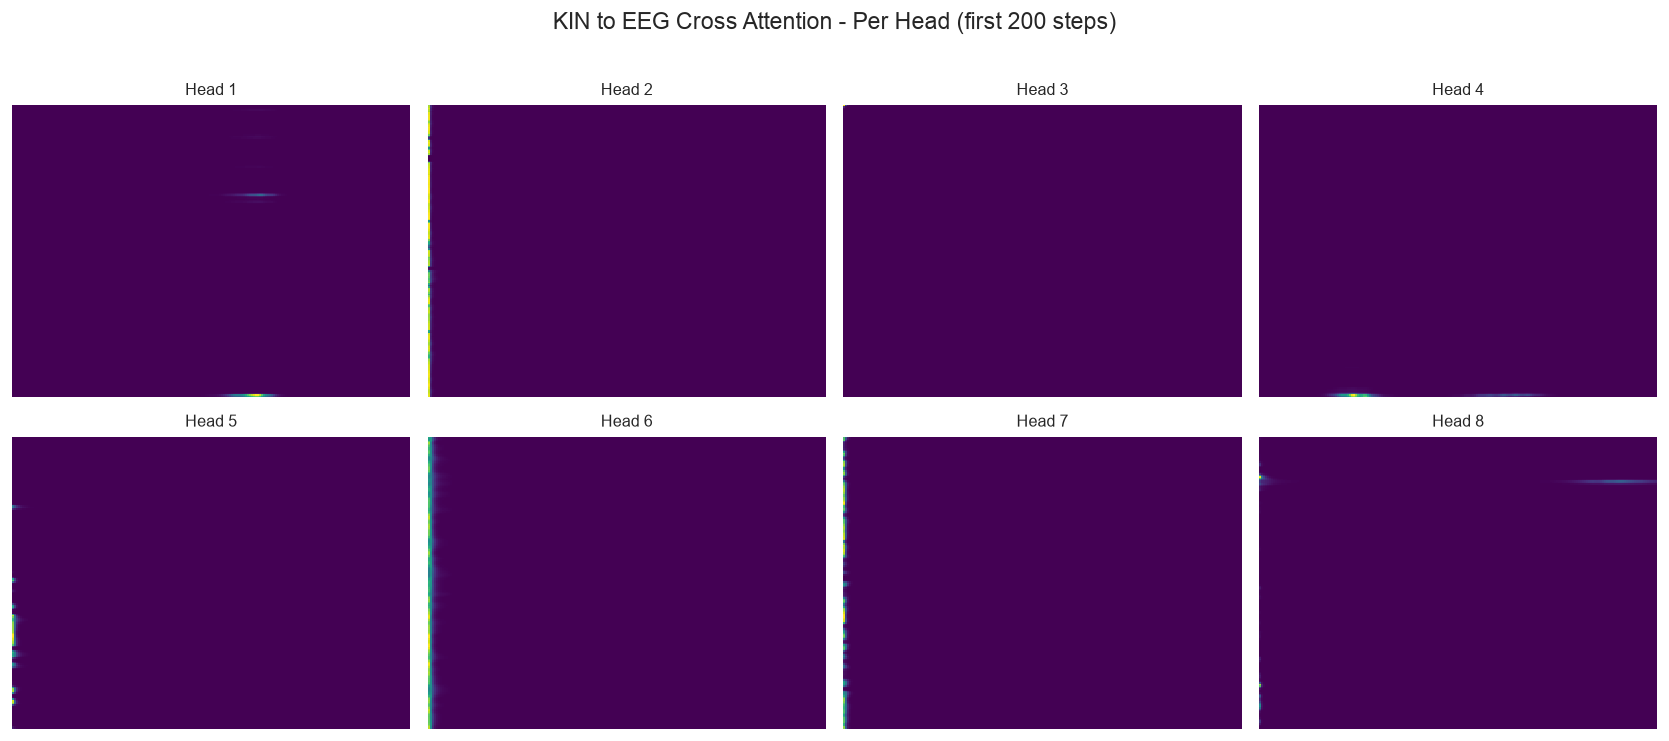

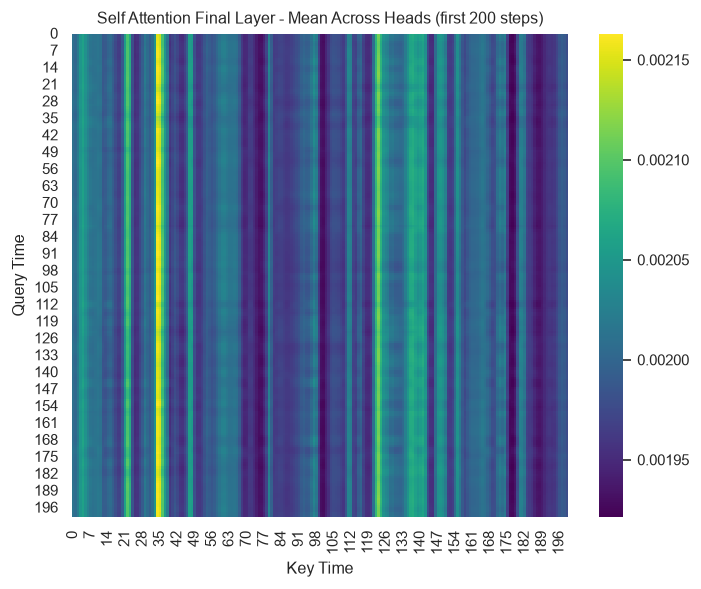

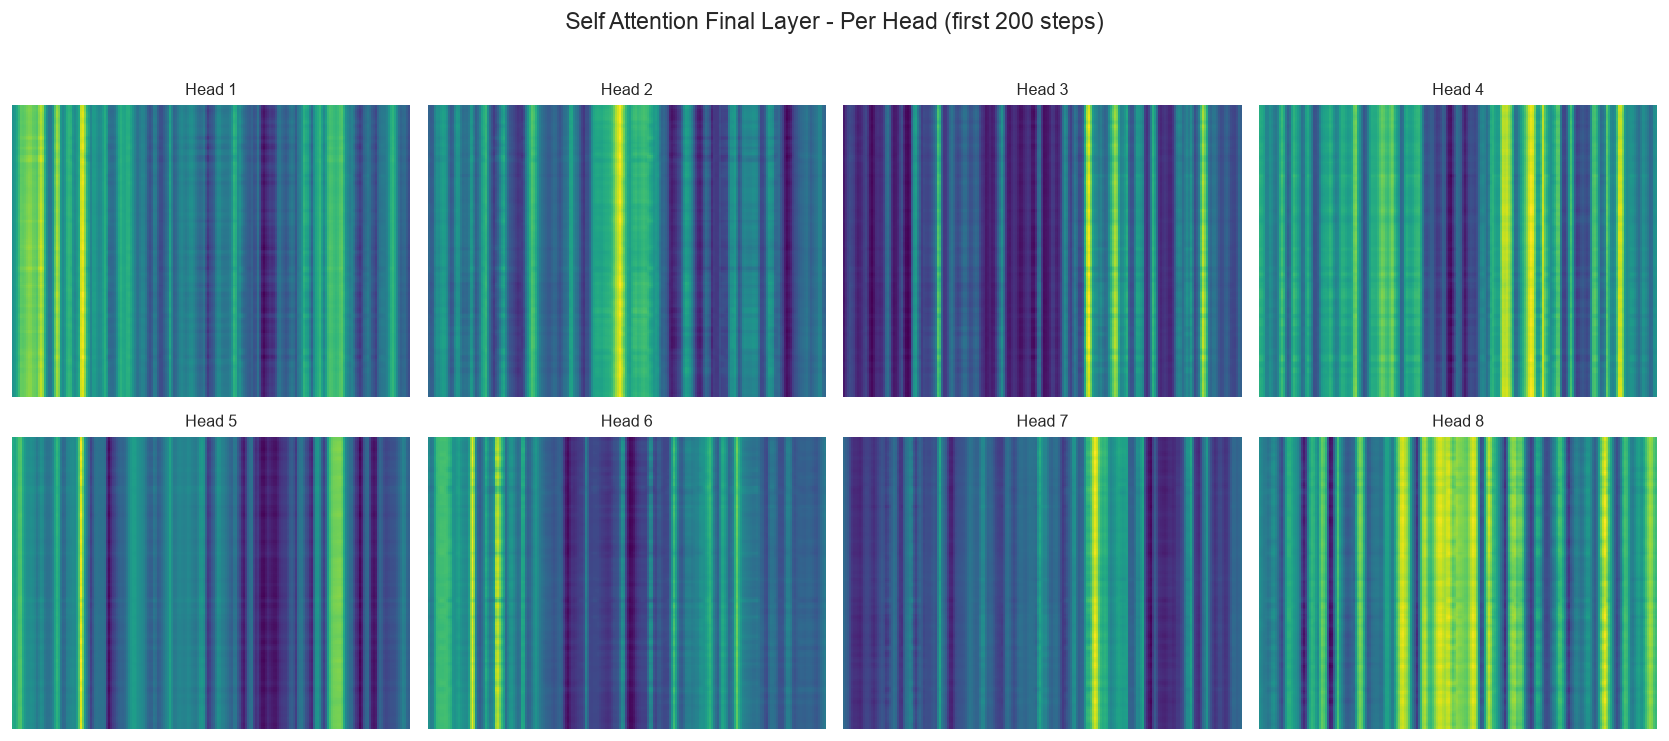

In [15]:
# @titlePlot Gate and Attention Maps

# Plot the Gated Fusion Heatmap
plot_gate_heatmap(interpret_dict["gate"], sample_idx=0, cfg=notebook_cfg)
plt.show()
# Plot Dual Cross-Attention
plot_attention_maps(interpret_dict["cross_attn_eeg_kin"], "EEG to KIN Cross Attention", cfg=notebook_cfg)
plot_attention_maps(interpret_dict["cross_attn_kin_eeg"], "KIN to EEG Cross Attention", cfg=notebook_cfg)

# Plot Self-Attention (Final Layer = -1)
plot_attention_maps(interpret_dict["self_attn"][-1], "Self Attention Final Layer", cfg=notebook_cfg)
plt.show()

Running rigorous K-Fold evaluation across all models...
Evaluating Fold 1/5...
Evaluating Fold 2/5...
Evaluating Fold 3/5...
Evaluating Fold 4/5...
Evaluating Fold 5/5...

------------------------------------------------------------
 FINAL K-FOLD SCIENTIFIC BENCHMARK (Mean Â± Std)
------------------------------------------------------------
            Channel           RMSE            MAE        Pearson
       Ant. Deltoid 0.021 Â± 0.000 0.014 Â± 0.000 0.895 Â± 0.002
    Ext. Carpi Rad. 0.004 Â± 0.000 0.003 Â± 0.000 0.823 Â± 0.003
    Flex. Digitorum 0.004 Â± 0.000 0.002 Â± 0.000 0.792 Â± 0.005
    Ext. Dig. Comm. 0.009 Â± 0.000 0.006 Â± 0.000 0.904 Â± 0.001
1st Dors. Inteross. 0.004 Â± 0.000 0.002 Â± 0.000 0.802 Â± 0.007
       OVERALL MEAN 0.008 Â± 0.007 0.005 Â± 0.004 0.843 Â± 0.048

Raw test metrics successfully saved to: results\P4\ep50_st250_lr0.0001_bs32\kfold_test_metrics.csv

Saving and Plotting Continuous Trajectories for ALL Folds...
Plotting fold_1...
Saved figure:
  resul

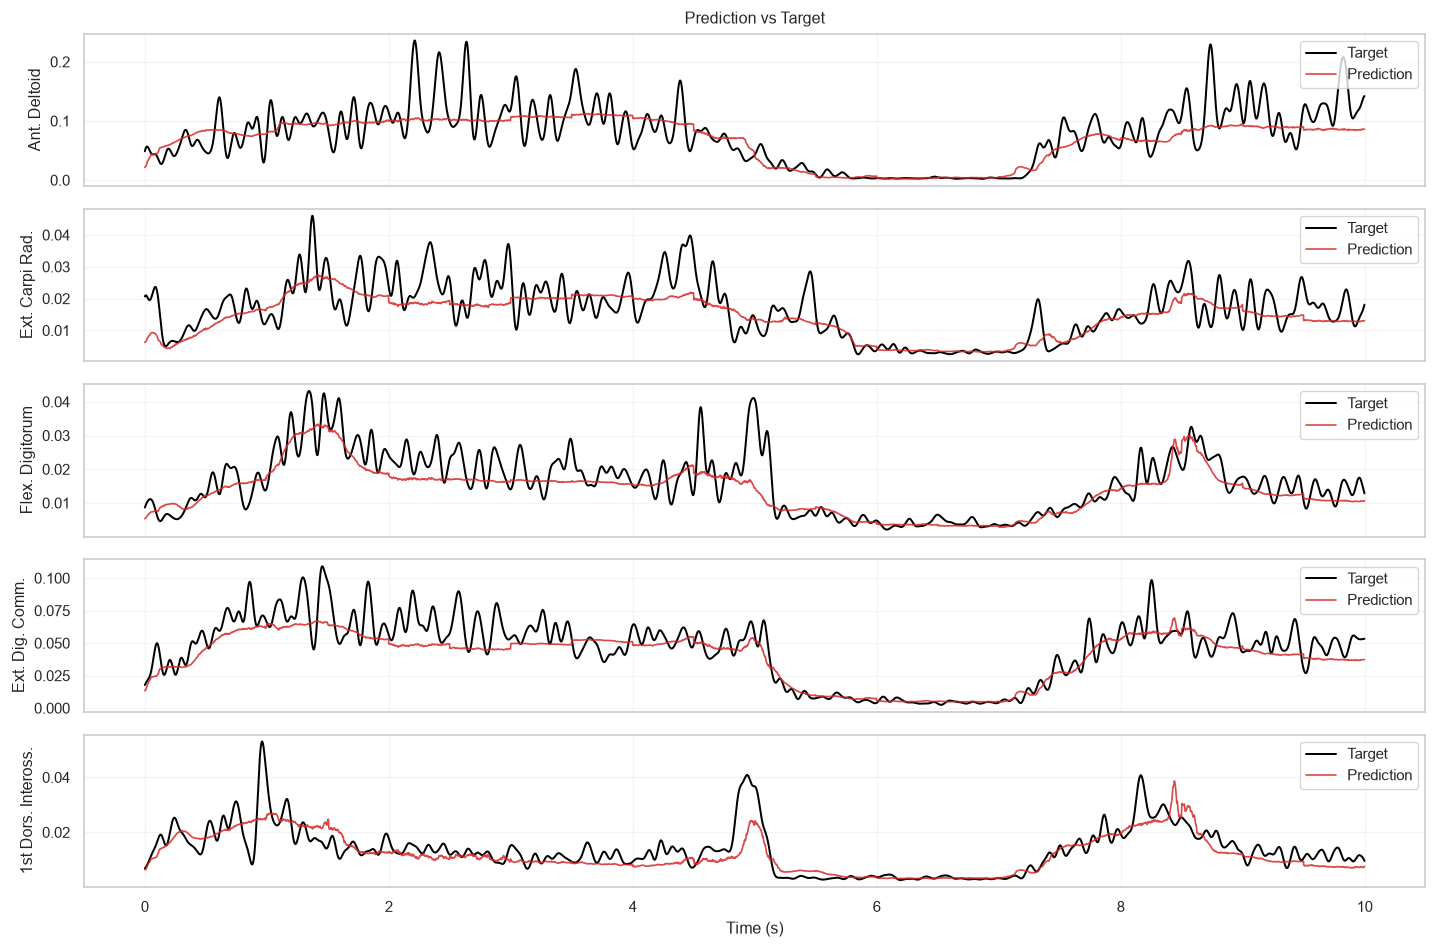

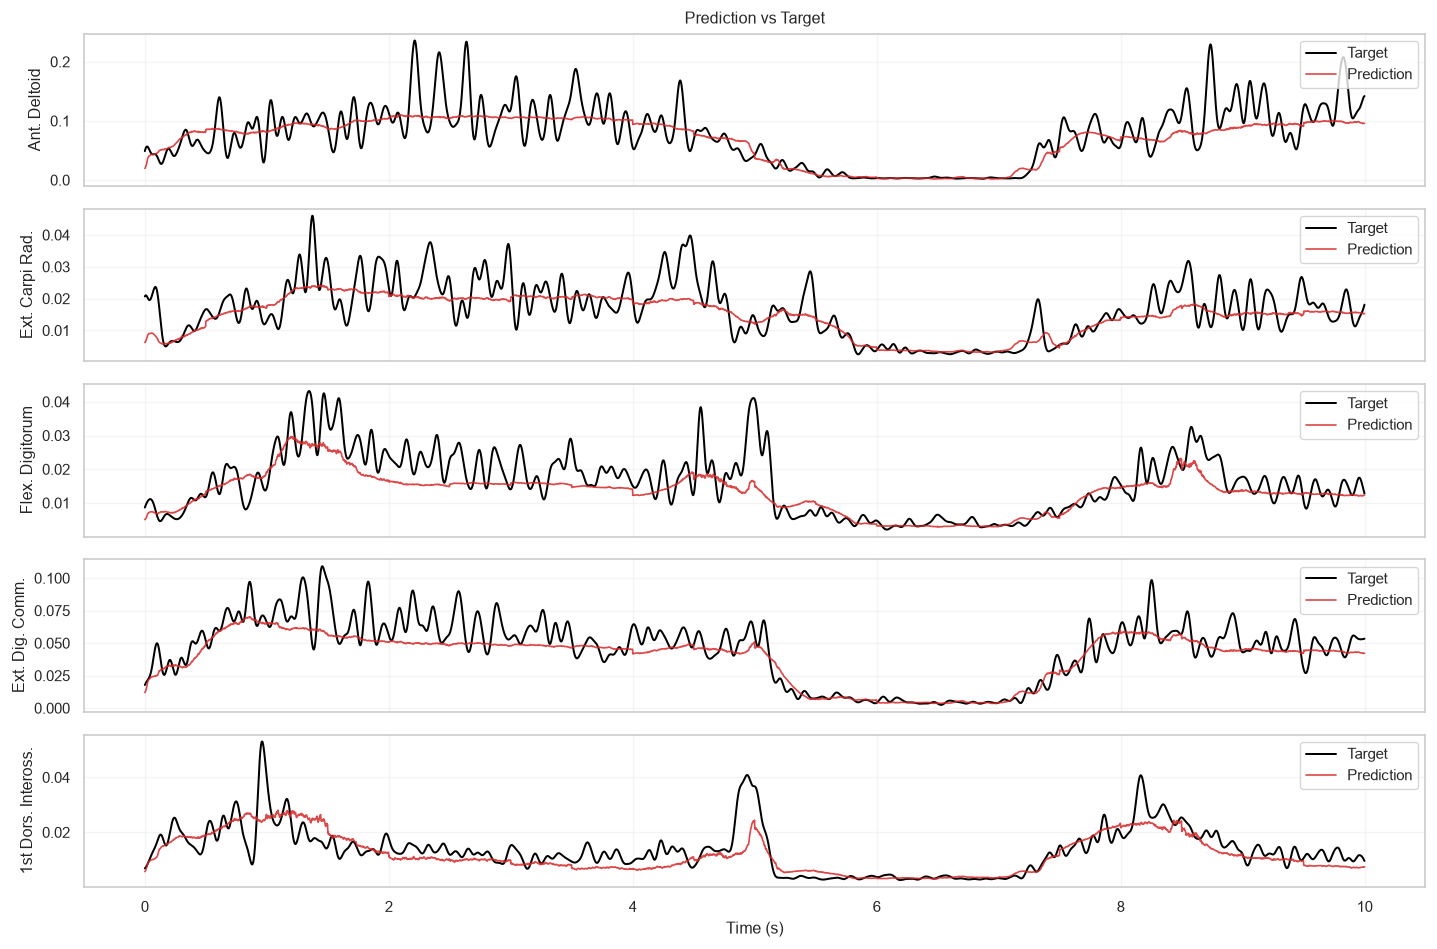

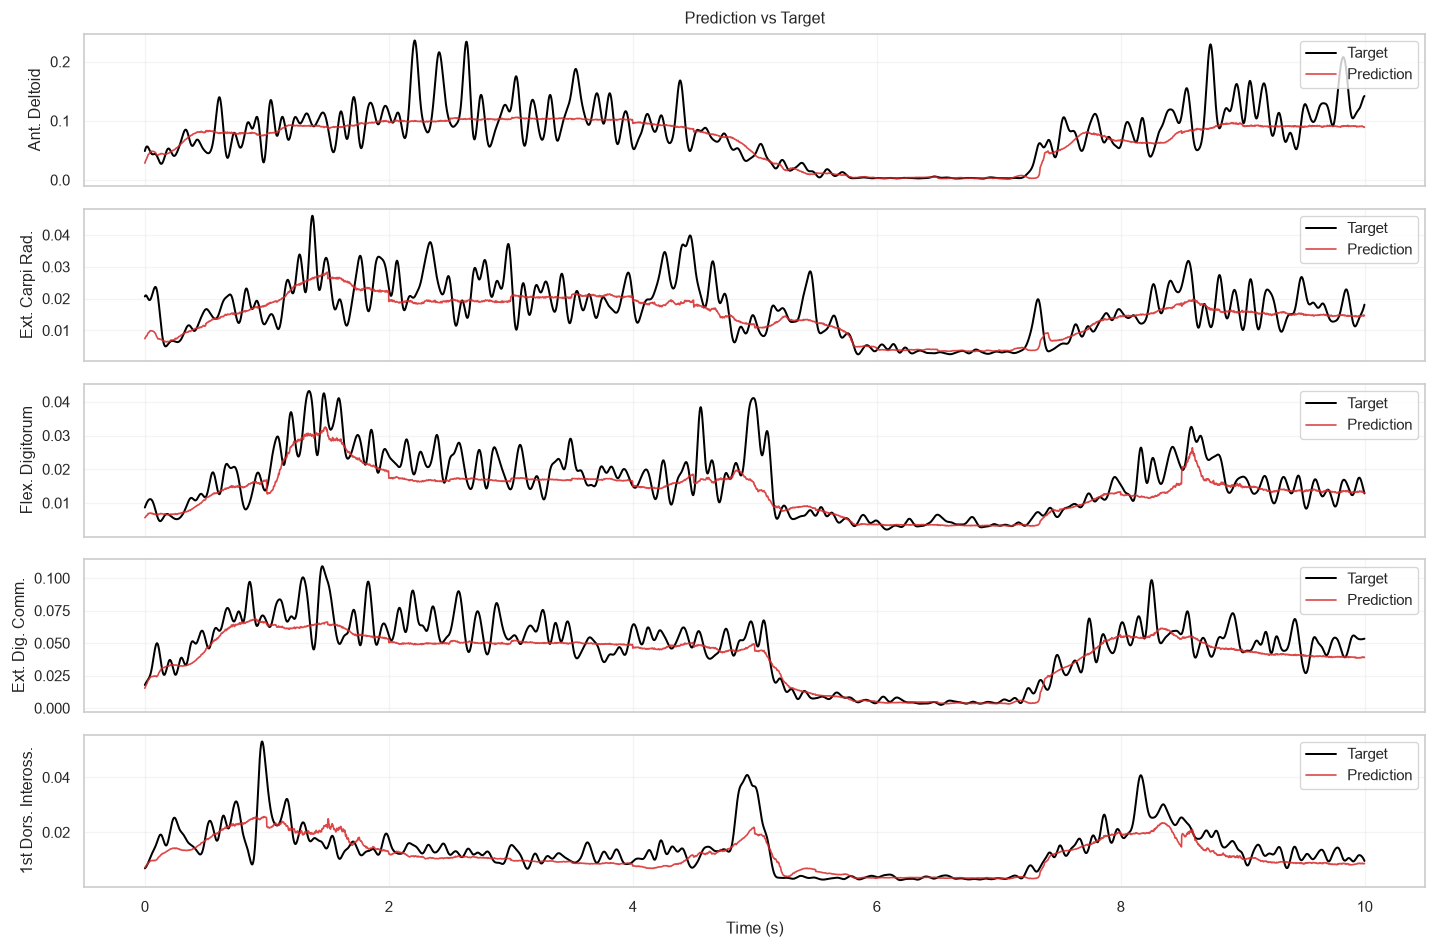

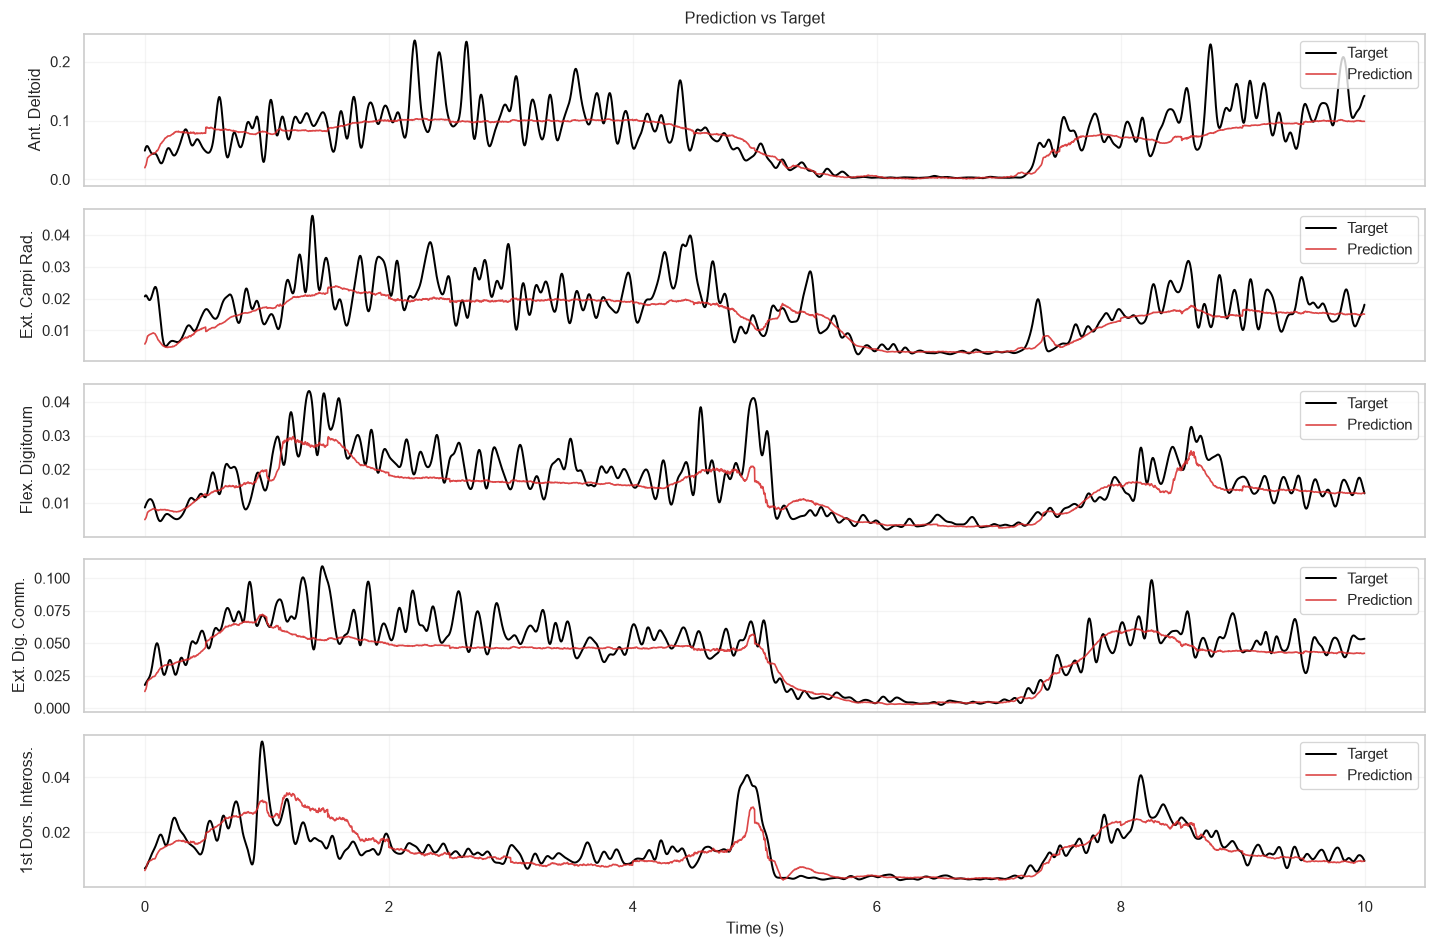

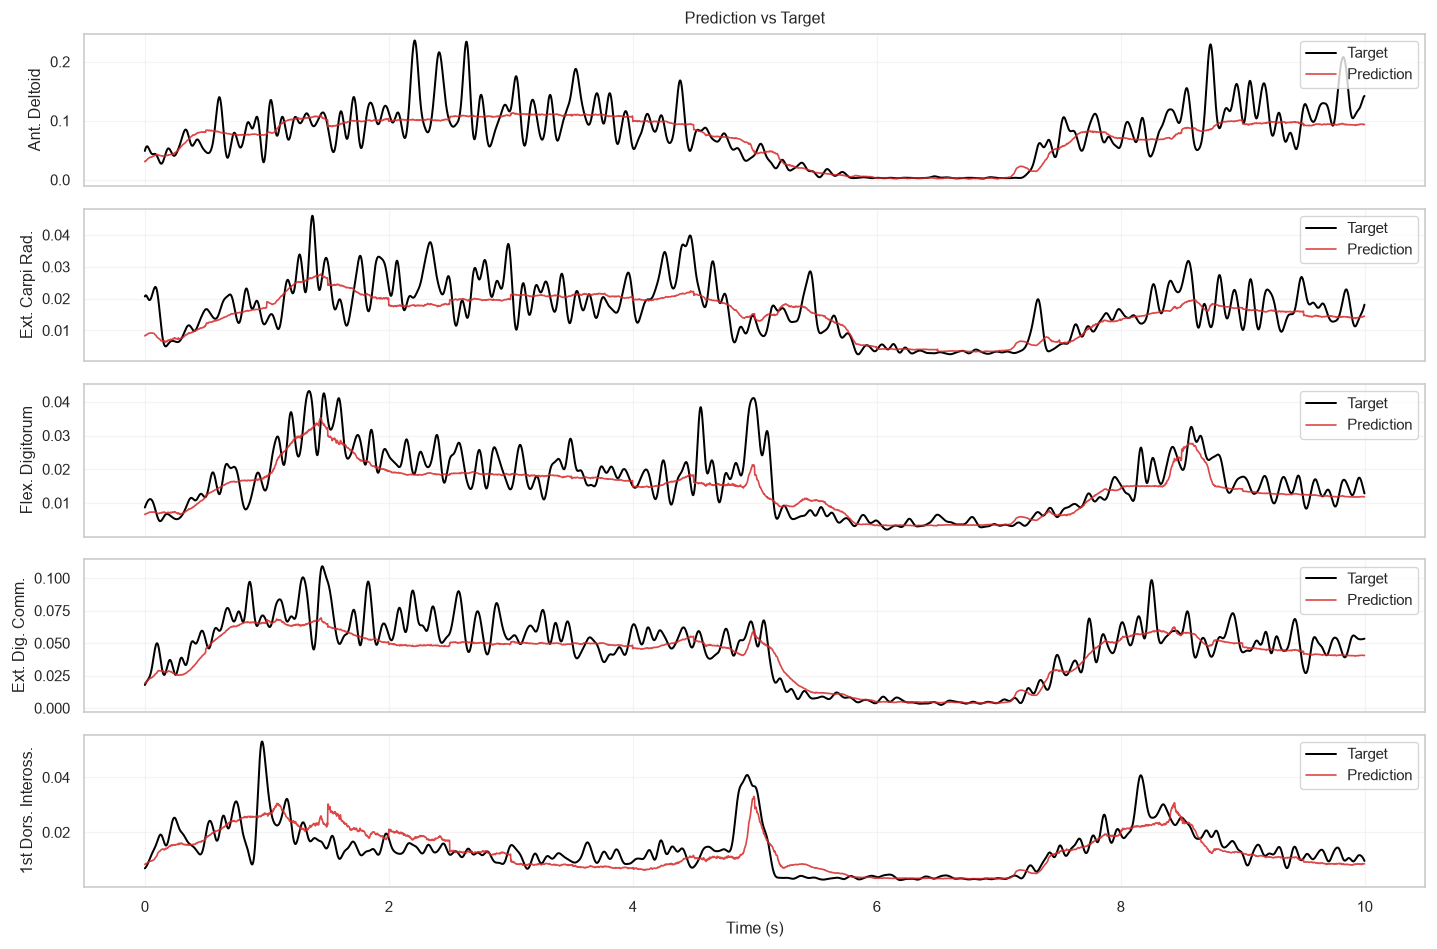

In [16]:
# @title Rigorous K-Fold Continuous Evaluation

print("Running rigorous K-Fold evaluation across all models...")

EMG_CHANNEL_NAMES = [
    "Ant. Deltoid",
    "Ext. Carpi Rad.",
    "Flex. Digitorum",
    "Ext. Dig. Comm.",
    "1st Dors. Inteross.",
]

# Ensure we have a fresh base model in memory
sample_eeg, sample_kin, sample_emg = test_ds[0]
dummy_eeg = torch.as_tensor(sample_eeg).unsqueeze(0)
dummy_kin = torch.as_tensor(sample_kin).unsqueeze(0)
dummy_emg = torch.as_tensor(sample_emg).unsqueeze(0)

# We use prepare_batch to get the true dimensions after feature dropping
batch_inputs, _ = prepare_batch(dummy_eeg, dummy_kin, dummy_emg)

model = build_model_from_config(
    notebook_cfg, 
    input_dim=batch_inputs["eeg"].shape[-1], 
    kin_dim=batch_inputs["kin"].shape[-1]
).to(device)

# Initialize storage for our metrics and predictions
k_fold_metrics = []
all_predictions = {}   
all_targets = {}       

for fold_idx, res in enumerate(all_fold_results):
    print(f"Evaluating Fold {fold_idx + 1}/{len(all_fold_results)}...")
    
    # 1. Load the full checkpoint dictionary from the hard drive
    checkpoint_path = get_checkpoint_path(notebook_cfg, fold_idx)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract JUST the model weights from the dictionary and load them
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    
    # 2. Predict the full continuous sequence
    pred_full, target_full = predict_full_series_from_dataset(
        model=model,
        ds=test_ds,
        prepare_batch=prepare_batch,
        emg_mean=emg_mean_tensor,
        emg_std=emg_std_tensor,
        device=device,
        series_idx=0, 
    )
    all_predictions[f"fold_{fold_idx + 1}"] = pred_full.copy()
    all_targets[f"fold_{fold_idx + 1}"] = target_full.copy()
    
    # 3. Calculate metrics for each of the 5 channels
    for c in range(5):
        p = pred_full[:, c]
        t = target_full[:, c]
        
        rmse = np.sqrt(np.mean((p - t)**2))
        mae = np.mean(np.abs(p - t))
        corr, _ = pearsonr(p, t)
        
        k_fold_metrics.append({
            "Fold": fold_idx + 1,
            "Channel": EMG_CHANNEL_NAMES[c],
            "RMSE": rmse,
            "MAE": mae,
            "Pearson": corr
        })

# Convert to DataFrame for easy analysis
df_all = pd.DataFrame(k_fold_metrics)

# Calculate Mean and Std Deviation across folds for each channel
summary_rows = []
for channel in EMG_CHANNEL_NAMES:
    ch_data = df_all[df_all["Channel"] == channel]
    summary_rows.append({
        "Channel": channel,
        "RMSE": f"{ch_data['RMSE'].mean():.3f} Â± {ch_data['RMSE'].std():.3f}",
        "MAE": f"{ch_data['MAE'].mean():.3f} Â± {ch_data['MAE'].std():.3f}",
        "Pearson": f"{ch_data['Pearson'].mean():.3f} Â± {ch_data['Pearson'].std():.3f}"
    })

df_summary = pd.DataFrame(summary_rows)

# Calculate the Grand Mean across everything
overall_rmse_mean = df_all['RMSE'].mean()
overall_rmse_std = df_all['RMSE'].std()
overall_mae_mean = df_all['MAE'].mean()
overall_mae_std = df_all['MAE'].std()
overall_pearson_mean = df_all['Pearson'].mean()
overall_pearson_std = df_all['Pearson'].std()

# Add the final TOTAL row
df_summary.loc[len(df_summary)] = {
    "Channel": "OVERALL MEAN",
    "RMSE": f"{overall_rmse_mean:.3f} Â± {overall_rmse_std:.3f}",
    "MAE": f"{overall_mae_mean:.3f} Â± {overall_mae_std:.3f}",
    "Pearson": f"{overall_pearson_mean:.3f} Â± {overall_pearson_std:.3f}"
}

print("\n" + "-"*60)
print(" FINAL K-FOLD SCIENTIFIC BENCHMARK (Mean Â± Std)")
print("-"*60)
print(df_summary.to_string(index=False))

# Save the raw data to your config folder!
csv_path = checkpoint_path.parent.parent.parent / "kfold_test_metrics.csv"
df_all.to_csv(csv_path, index=False)
print(f"\nRaw test metrics successfully saved to: {csv_path}")

start_idx = 5000 
end_idx = 10000 

print("\nSaving and Plotting Continuous Trajectories for ALL Folds...")

for fold_name in all_predictions.keys():
    print(f"Plotting {fold_name}...")
    
    notebook_cfg["training"]["current_fold"] = fold_name
    
    plot_prediction_overlay(
        pred=all_predictions[fold_name][start_idx:end_idx], 
        target=all_targets[fold_name][start_idx:end_idx], 
        fs=500, 
        channel_names=EMG_CHANNEL_NAMES, 
        cfg=notebook_cfg
    )

Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\fold_5\plots\residual_diagnostics_ch0.png
  results\P4\ep50_st250_lr0.0001_bs32\fold_5\plots\residual_diagnostics_ch0.pdf


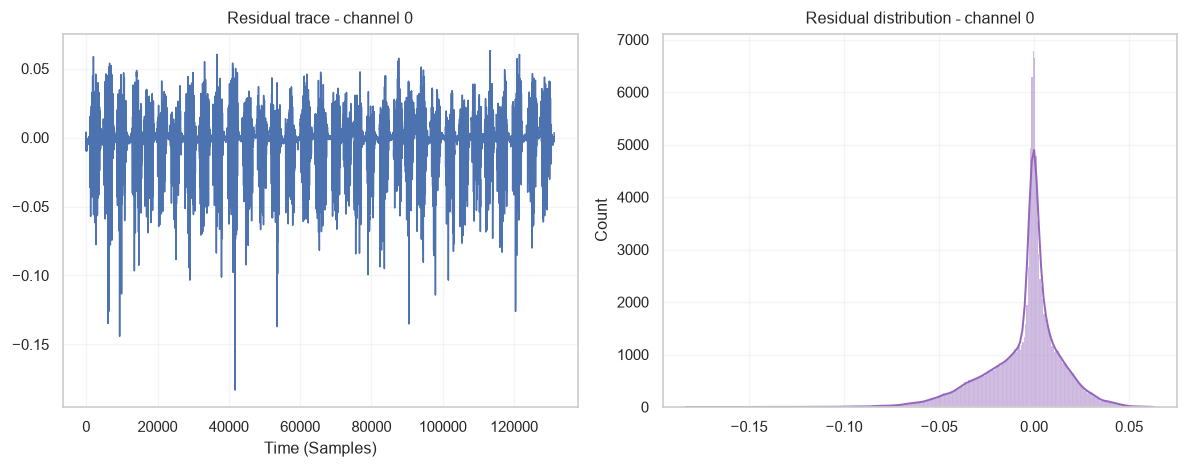

In [17]:
plot_residual_diagnostics(pred_full, target_full, channel_idx=0, cfg=notebook_cfg);

Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\fold_5\plots\fused_pca_scatter.png
  results\P4\ep50_st250_lr0.0001_bs32\fold_5\plots\fused_pca_scatter.pdf


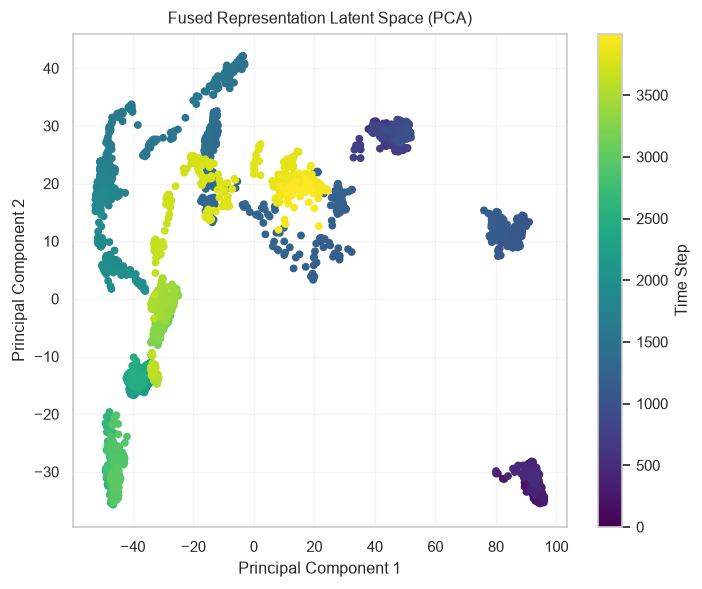

In [18]:
plot_fused_pca(interpret_dict["fused"], sample_idx=0, cfg=notebook_cfg);

Saved figure:
  results\P4\ep50_st250_lr0.0001_bs32\fold_5\plots\gate_vs_emg_power.png
  results\P4\ep50_st250_lr0.0001_bs32\fold_5\plots\gate_vs_emg_power.pdf


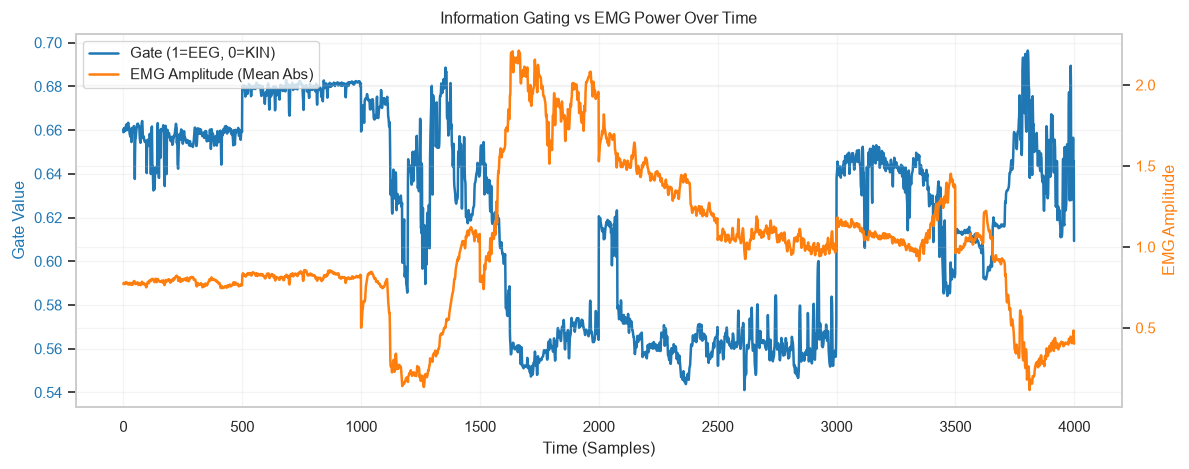

In [19]:
plot_gate_vs_emg_power(interpret_dict["gate"], preds, sample_idx=0, cfg=notebook_cfg);
